# Lecture 12 Movement Grammars
This is Lecture 12 of Fall 2026 Computational Linguistics I at Cornell.

We use Edward Stabler's parser `mgcky-swi`, `swipl` prolog, and a prolog Jupyter kernel. 
For setup see [the mg repository](https://github.com/MatsRooth/mg).

## Demo prolog

In [1]:
member(X, [mommy, likes, cookies]).

X = mommy

In [2]:
jupyter:retry.

% Retrying goal: member(X,[mommy,likes,cookies])


X = likes

In [3]:
jupyter:retry.

% Retrying goal: member(X,[mommy,likes,cookies])


X = cookies

In [ ]:
jupyter:retry.

% Retrying goal: member(X,[mommy,likes,cookies])


false

## Load the MG parser

In [5]:
consult('../code/mgcky-swi/setup.pl').

true

## Reset the grammar

In [6]:
['grammars/gh6.pl'].

true

## Parse a sentence

In [6]:
parse([the,king,laugh,'-s'], 'C', D).

analyzing...
runtime:18.
chartlength:43.
accepted as category C: the king laugh -s

D = [0,8,57,66,20,26,13]

#### Reconstruct the derivation steps

In [7]:
lparse([0,8,57,66,20,26,13], T, B, X, Lex, Deps).

T = [([],[],[the,king,laugh,-s]):[C]]/[[[]::[=T,C]]/[],[([the,king],[],[laugh,-s]):[T]]/[[([],[],[laugh,-s]):[+k,T],[the,king]:[-k]]/[[[-s]::[v==>,+k,T]]/[],[([],[laugh],[]):[v],[the,king]:[-k]]/[[([],[laugh],[]):[=D,v]]/[[[]::[=>V,=D,v]]/[],[[laugh]::[V]]/[]],[([],[the],[king]):[D,-k]]/[[[the]::[=Num,D,-k]]/[],[([],[],[king]):[Num]]/[[[]::[=N,Num]]/[],[[king]::[N]]/[]]]]]]],
B = (<)/[([]:[C])/[],(>)/[(<)/[([the]:[])/[],(<)/[([]:[])/[],([king]:[])/[]]],(<)/[([]:[])/[],(>)/[/[],(<)/[<o/[o> / [[laugh]/[],([]:[])/[]],[-s]/[]],([]:[])/[]]]]]],
X = CP/[C'/[C/[[]/[]],TP/[DP(0)/[D'/[D/[[the]/[]],NumP/[Num'/[Num/[[]/[]],NP/[N'/[N/[[king]/[]]]]]]]],T'/[T/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[v/[V/[[laugh]/[]],v/[[]/[]]],T/[[-s]/[]]],VP/[V'/[V/[t/[]]]]]]]]]],
Lex = [[]::[=T,C],[-s]::[v==>,+k,T],[]::[=>V,=D,v],[laugh]::[V],[the]::[=Num,D,-k],[]::[=N,Num],[king]::[N]],
Deps = [1=[],5=[the],6=[],7=[king],4=[laugh],3=[],2=[-s]],[(1:1->2),(2:2->5),(2:1->hr(3)),(3:2->5),(3:1->li(4)),(5:1->6),(6:1->7)]

In [8]:
lparse([0,8,57,66,20,26,13], _, _, X, _, _),pptree(X).

'CP' /[
    'C\'' /[
        'C' /[
            [] /[]],
        'TP' /[
            'DP'(0) /[
                'D\'' /[
                    'D' /[
                        [the] /[]],
                    'NumP' /[
                        'Num\'' /[
                            'Num' /[
                                [] /[]],
                            'NP' /[
                                'N\'' /[
                                    'N' /[
                                        [king] /[]]]]]]]],
            'T\'' /[
                'T' /[
                    t /[]],
                vP /[
                    'DP' /[
                        t(0) /[]],
                    'v\'' /[
                        v /[
                            v /[
                                'V' /[
                                    [laugh] /[]],
                                v /[
                                    [] /[]]],
                            'T' /[
                                ['-s'] 

X = CP/[C'/[C/[[]/[]],TP/[DP(0)/[D'/[D/[[the]/[]],NumP/[Num'/[Num/[[]/[]],NP/[N'/[N/[[king]/[]]]]]]]],T'/[T/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[v/[V/[[laugh]/[]],v/[[]/[]]],T/[[-s]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]

## View tree in a popup

In [10]:
once(parse(['Titus',laugh,'-s'], 'C', D)),
lparse(D, _, _, X, _, _),
wish_tree(X).

analyzing...
runtime:17.
chartlength:41.
accepted as category C: Titus laugh -s

D = [0,8,57,66,28],
X = CP/[C'/[C/[[]/[]],TP/[DP(0)/[D'/[D/[[Titus]/[]]]],T'/[T/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[v/[V/[[laugh]/[]],v/[[]/[]]],T/[[-s]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]

## Inline tree display

In [11]:
consult('../code/inline_tree.pl').

true

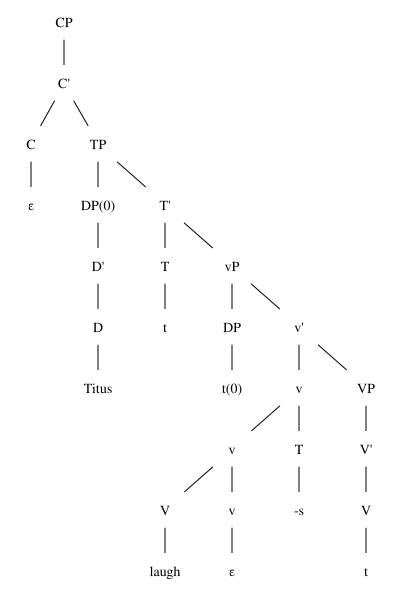

true

analyzing...
runtime:10.
chartlength:41.
accepted as category C: Titus laugh -s

D = [0,8,57,66,28],
X = CP/[C'/[C/[[]/[]],TP/[DP(0)/[D'/[D/[[Titus]/[]]]],T'/[T/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[v/[V/[[laugh]/[]],v/[[]/[]]],T/[[-s]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]

In [12]:
once(parse(['Titus',laugh,'-s'], 'C', D)),
lparse(D, _, _, X, _, _),
inline_tree(X).

The popup is better.  Here it is in a snapshot.

![Titus will laugh](img/titus-will-s-laugh.png)

## Head movement
In the tree abouve *will* starts up in the Modal node that appears as a trace.  It has moved up one step by *head movement*, to combine with the present tense *-s*.

Discuss: how should this sequence of morphemes be handled by the morpho-phonology, using the methodology of Lecture 11?

This is the lexical entry for present tense.
```
['-s']::[=>'Modal',+k,'T']
```
The last *result* part of the tuple says that the category of present tense it `T` (tense), so that a complete phrase formed from present tense is a TP.

The first part says, first, that present tense combines with a complete `ModalP`.

The first part says, secondly, that head movement of the head of `ModalP` is triggered.  In the tree, the head `will` of ModalP has moved up to combine with `-s`.

#### Head movement iterating
In this example, `[will -s]` moves a step further, to the head of `C` to form a question.

In [13]:
once(parse([will,'-s','Titus',laugh], 'C', D)),
lparse(D, _, _, X, _, _),
wish_tree(X).

analyzing...
runtime:11.
chartlength:42.
accepted as category C: will -s Titus laugh

D = [1,9,52,57,66,28],
X = CP/[C'/[C/[T/[Modal/[[will]/[]],T/[[-s]/[]]],C/[[]/[]]],TP/[DP(0)/[D'/[D/[[Titus]/[]]]],T'/[T/[t/[]],ModalP/[Modal'/[Modal/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[V/[[laugh]/[]],v/[[]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]]]

![Titus will laugh](img/will-s-titus-laugh.png)

This movement is triggered by an empty complementizer `C`.
```
[]::[=>'T','C'].
```

The other derivations also used an empty complementizer, to convert `TP` into the start category `CP`.
```

```

## Simple arguments
The other derivations also used an empty complementizer, to convert `TP` into the start category `CP`.
```
[]::[='T','C'].
```
This is read: a lexical item with spelling form empty string combines with a TP to form a CP.  

Minimalist grammar uses a rigid convention for phrase order, where the first argument goes to the right, and subsequent arguments go to the left. 

In the lexical entry, `='T'` indicates an argument TP, and as before `C` indicates a result category `CP`.

In [14]:
once(parse([will,'-s','Titus,laugh], 'C', D)),
lparse(D, _, _, X, _, _),
wish_tree(X).

analyzing...
runtime:8.
chartlength:44.
accepted as category C: will -s the king laugh

D = [1,9,52,57,66,20,26,13],
X = CP/[C'/[C/[T/[Modal/[[will]/[]],T/[[-s]/[]]],C/[[]/[]]],TP/[DP(0)/[D'/[D/[[the]/[]],NumP/[Num'/[Num/[[]/[]],NP/[N'/[N/[[king]/[]]]]]]]],T'/[T/[t/[]],ModalP/[Modal'/[Modal/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[V/[[laugh]/[]],v/[[]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]]]

## DPs
These are lexical entries for DPs. They are complete DPs by themselves, and have no arguments.
```
['Titus']::['D',-k].         
['Lavinia']::['D',-k].      
['Tamara']::['D',-k].
```
The information `-k` indicates a *requirement to move* to a position that supplies `+k`.  An example is `will`, which supplies `+k`.
```
```
![Titus will laugh](img/titus-will-s-laugh.png)

This is a lexical entry for present tense, one of several.

['-s']::[=>'Modal',+k,'T']
The last result part of the tuple says that the category of present tense it T (tense), so that a complete phrase formed from present tense is a TP.

The first part says, first, that present tense combines with a complete ModalP.

The first part says, secondly, that head movement of the head of ModalP is triggered. In the tree, the head will of ModalP has moved up to combine with -s.

The middle part `+k` says that present tense licenses movement of a `-k` phrase to the *Subject* or *SPEC* position of the `TP`. This is the earliese position directly below `TP`.

## WH movement
The mechanism above is *feature driven movement*.  In general, `-f` phrase has to move to a position that provides
`+f`.  This is also used for *wh* movement.

In [14]:
once(parse([which,king,will,'-s',laugh], 'C', D)),
lparse(D, _, _, X, _, _),
wish_tree(X).

analyzing...
runtime:31.
chartlength:89.
accepted as category C: which king will -s laugh

D = [3,9,52,57,66,46,26,13],
X = CP/[DP(0)/[D'/[D/[[which]/[]],NumP/[Num'/[Num/[[]/[]],NP/[N'/[N/[[king]/[]]]]]]]],C'/[C/[[]/[]],TP/[DP(0)/[t(0)/[]],T'/[T/[Modal/[[will]/[]],T/[[-s]/[]]],ModalP/[Modal'/[Modal/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[V/[[laugh]/[]],v/[[]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]]]

![Titus will laugh](img/which-king-will-s-laugh.png)

`which king` is a `DP -wh`, meaning it has to move to a position that supplies `+wh`.  This is another empty `C`.
```
[]::[='T',+wh,'C'].
```

It combines with `TP` to form `CP`, and licenses wh movement to SPEC of `CP`.  In the tree above, `[will -s]` remains the head of TP.

In [ ]:
## Affix hopping
Look at this tree.

In [18]:
once(parse([the,king,'-s',will,'-s',laugh], 'C', D)),
lparse(D, _, _, X, _, _),
wish_tree(X).

analyzing...
runtime:15.
chartlength:61.
accepted as category C: the king -s will -s laugh

D = [0,9,52,57,66,20,27,13],
X = CP/[C'/[C/[[]/[]],TP/[DP(0)/[D'/[D/[[the]/[]],NumP/[Num'/[Num/[t/[]],NP/[N'/[N/[N/[[king]/[]],Num/[[-s]/[]]]]]]]]],T'/[T/[Modal/[[will]/[]],T/[[-s]/[]]],ModalP/[Modal'/[Modal/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[V/[[laugh]/[]],v/[[]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]]]

![The king -s will -s laugh](img/the-king-s-will-s-laugh.png)

In [ ]:
The first `-s` is number marking on `[the king -s]`.  It is introduced with the category `Num`. It combines
with an NP.
```
['-s']::['N'==>,'Num']
```
The pattern of heads and traces is reminiscent of head movement, but works the opposite way. `-s` has moved *down* to the head of `NP`. 
This is affix hopping. Compare the notation above to the notation for head movement.
```
[]::[=>'T','C'].
```


In [21]:
once(parse([the,king,will,'-s',laugh], 'C', D)),
lparse(D, _, _, X, _, _),
wish_tree(X).

analyzing...
runtime:7.
chartlength:42.
accepted as category C: the king will -s laugh

D = [0,9,52,57,66,20,26,13],
X = CP/[C'/[C/[[]/[]],TP/[DP(0)/[D'/[D/[[the]/[]],NumP/[Num'/[Num/[[]/[]],NP/[N'/[N/[[king]/[]]]]]]]],T'/[T/[Modal/[[will]/[]],T/[[-s]/[]]],ModalP/[Modal'/[Modal/[t/[]],vP/[DP/[t(0)/[]],v'/[v/[V/[[laugh]/[]],v/[[]/[]]],VP/[V'/[V/[t/[]]]]]]]]]]]]

In a singular, there the number marking is empty, and there is no head movement.

![the king will -s laugh](img/the-king-will-s-laugh.png)

##  Overview
Movement grammar or minimalist grammar is a grammar formalism which, like context free grammar and feature grammar, describes a language as a set of labeled trees.  

MG is *lexicalized*, meaning that all the information is in the lexicon.

The main feature of movement grammars is that heads and phrases can move.  We saw three movement operations.

* Head movement
* Affix hopping
* Feature driven movement of `-f` to the SPEC of a head supplying `+f`.

A design idea is that these operations cut across different phenomena.  Feature driven movement applies to both subjects
and wh-movement.

Although parsing movement grammars is more complex that parsing CFGs, parsing is still feasible, and is polinomial in complexity. We will look at it in a subsequent lecture.